For the last assignnent, I looked at the PFOAs found in the kalamazoo river. we found that most of the water sampling sites along the kalamazoo river measured over the safety threshold for PFOAs contamination. However, Across the entire kalamazoo watershed, the kalamazoo river drains over 2,000 square miles. I Would like to expand my search into the whole kalamazoo watershed. I hypothesisze that the pollutants present within the kalamazoo river are also found within other waterbodies sampled by EGLE.  

<Item title:"Pfas_Surface_Water cluster webmap" type:Web Map owner:ian.m.walraven@wmich.edu>
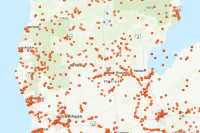

In [ ]:
#Imports
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from arcgis.gis import GIS
from arcgis.features import GeoAccessor
from arcgis.gis import GIS

#Bring up the webmap from arcGIS online
gis = GIS("https://www.arcgis.com", "ian.m.walraven@wmich.edu", "Th3rav3nonth3wall")
Map = gis.map("USA")

items = gis.content.search('title:"Pfas_Surface_Water cluster webmap"', item_type="Web Map")
webmap_item = items[0]
webmap = webmap_item
webmap







In [14]:
#bringing in the database for analysis

df = pd.read_csv("Pfas_Surface_Water (1).csv")
for col in df.columns:
    print(col)



X
Y
LabSampleId
SiteCode
CocSampleId
SampleType
LabName
LabJobName
Matrix
CollectionDate
AnalysisMethod
DilutionFactor
AnalysisDate
Duplicate
Unit
Watershed
Waterbody
LocationCode
HUC10
HUC8
Project
Description
AdditionalDescription
VisitID
SampleDepth
Longitude
Latitude
CAS307244_PFHxA
CAS307244_PFHxAFlag
CAS307244_PFHxAMdl
CAS307244_PFHxARl
CAS307551_PFDoA
CAS307551_PFDoAFlag
CAS307551_PFDoAMdl
CAS307551_PFDoARl
CAS335671_PFOA
CAS335671_PFOAFlag
CAS335671_PFOAMdl
CAS335671_PFOARl
CAS335762_PFDA
CAS335762_PFDAFlag
CAS335762_PFDAMdl
CAS335762_PFDARl
CAS335773_PFDS
CAS335773_PFDSFlag
CAS335773_PFDSMdl
CAS335773_PFDSRl
CAS355464_PFHxS
CAS355464_PFHxSFlag
CAS355464_PFHxSMdl
CAS355464_PFHxSRl
CAS356025_33FTCA
CAS356025_33FTCAFlag
CAS356025_33FTCAMdl
CAS356025_33FTCARl
CAS375224_PFBA
CAS375224_PFBAFlag
CAS375224_PFBAMdl
CAS375224_PFBARl
CAS375735_PFBS
CAS375735_PFBSFlag
CAS375735_PFBSMdl
CAS375735_PFBSRl
CAS375859_PFHpA
CAS375859_PFHpAFlag
CAS375859_PFHpAMdl
CAS375859_PFHpARl
CAS375928_PFHp

from the collumns above, we can see all the data that the EGLE surface sampleing sites collect. For now, I am only focusing on PFOAs. PFOAS, in this dataset, is measured by ppm. while any amount of PFOAs is potentially toxic for this study any amount of PFOAs greater than 8 ppm will be considered to be high in PFOAs

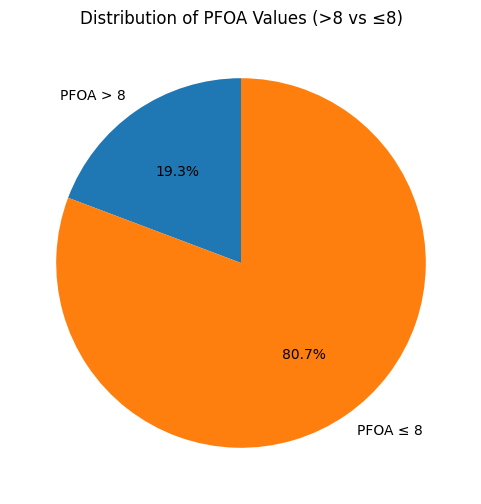

C:\Users\matth\AppData\Local\Temp\ipykernel_22048\643472289.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_pfoa["pfoa_bin"] = pd.cut(high_pfoa["CAS335671_PFOA"], bins=bins, labels=labels)


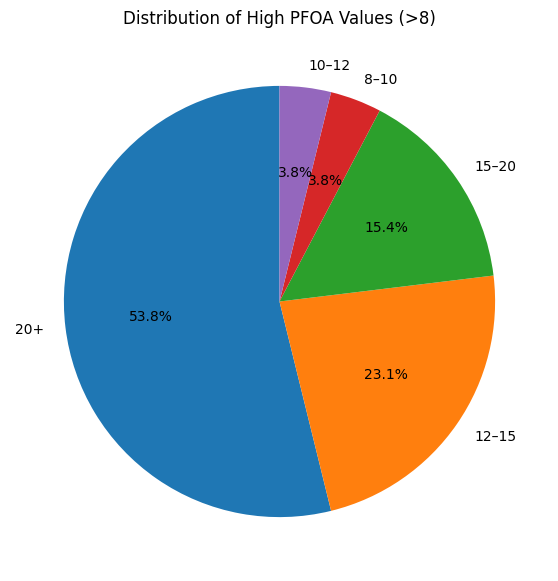

In [18]:
import matplotlib.pyplot as plt

#pie chart for amount of high/low PFOAs sites
counts = [
    len(df[df["CAS335671_PFOA"] > 8]),
    len(df[df["CAS335671_PFOA"] <= 8])
]

labels = ["PFOA > 8", "PFOA ≤ 8"]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of PFOA Values (>8 vs ≤8)")
plt.show()


#pie chart of amounts within the high PFOas sites
bins = [8, 10, 12, 15, 20, high_pfoa["CAS335671_PFOA"].max()]
labels = ["8–10", "10–12", "12–15", "15–20", "20+"]

high_pfoa["pfoa_bin"] = pd.cut(high_pfoa["CAS335671_PFOA"], bins=bins, labels=labels)

counts = high_pfoa["pfoa_bin"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of High PFOA Values (>8)")
plt.show()


From here we can see that a majority of surface sampling sites have relativly safe amounts of PFOAs. However, a little less than 20% of samples have high percentages of PFOAs. The second pie chart looks at the differing ranges of PFOAs within that high PFOAs data. WE can see that most of our high PFOAs areas are extremely high in PFOAs. These areas with extremely high amounts of PFOAs would in theory be near city centers and industrial areas across the state. I would like to know where these high points are at spatially and if they are somewhat correlated.  

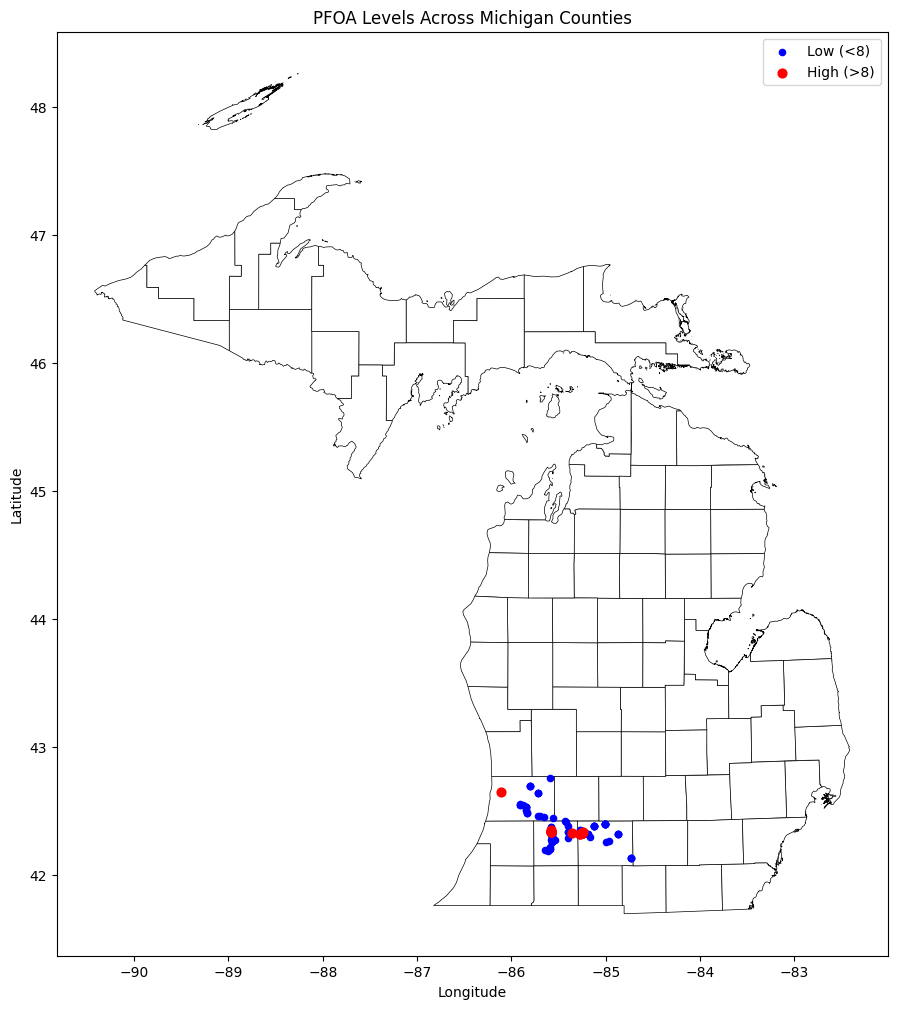

In [38]:
fig, ax = plt.subplots(figsize=(12, 12))

# 1. Plot Michigan counties first (background)
gdf_mi_counties_ee.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.5
)

# 2. Plot LOW PFOA points (blue)
gdf[gdf["pfoa_level"] == "Low (<8)"].plot(
    ax=ax,
    color="blue",
    markersize=20,
    label="Low (<8)"
)

# 3. Plot HIGH PFOA points (red)
gdf[gdf["pfoa_level"] == "High (>8)"].plot(
    ax=ax,
    color="red",
    markersize=40,
    label="High (>8)"
)

# 4. Add legend + title
plt.legend()
plt.title("PFOA Levels Across Michigan Counties")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


We can see that the high points PFOAs points are clustered in three areas. The nortern parts of Kalamazoo, Calhoun, and Allegan counties. These hot spots seem to be near Kalamazoo township, Galesburg township, and Mamlius twonship. All of these citys have one thing in common, they are known for their historic paper industries. Before the EPA was founded, paper mills across michigan would dump waste and pulp byproduct into the kalamazoo river. Since the closing of these mills over 50 years ago, most of the kalamazoo river PFOAs has decreased to potentially non-hazardous amounts. However, these chemicals have not fully gone away as there are still high amounts of PFOAs  near the orignial dump sites.  

In [48]:
import geopandas as gpd
from arcgis.gis import GIS

# 1. Ensure geometry column is set correctly
if "geometry" in gdf.columns:
    gdf = gdf.set_geometry("geometry")
elif "GEOMETRY" in gdf.columns:
    gdf = gdf.set_geometry("GEOMETRY")

# 2. Export to GeoJSON (AGOL-friendly)
gdf.to_file("pfoa.geojson", driver="GeoJSON")

# 3. Upload GeoJSON to ArcGIS Online (must specify type)
item = gis.content.add(
    {
        "title": "PFOA_HighLow",
        "type": "GeoJson"
    },
    data="pfoa.geojson"
)

# 4. Publish as Hosted Feature Layer
published = item.publish()

published



c:\Users\matth\Downloads\myenv\Lib\site-packages\IPython\core\interactiveshell.py:3747: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


<Item title:"PFOA_HighLow" type:Feature Layer Collection owner:ian.m.walraven@wmich.edu>